<a href="https://colab.research.google.com/github/Saiful-2/telco-customer-churn/blob/main/notebooks/06_telco_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom Customer Churn - Feature Engineering

In [1]:
# =========================================
# 1. Import Required Libraries
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =========================================
# 2. Load Cleaned Dataset
# =========================================

url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/cleaned-telco-customer-churn.csv"

df = pd.read_csv(url)

In [3]:
# =========================================
# 3. Display First 5 Rows
# =========================================

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
# =========================================
# 4. Check Dataset Shape
# =========================================

df.shape

(7032, 20)

In [5]:
# =========================================
# 5. Dataset Information
# =========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 


In [6]:
# =========================================
# 6. Check Existing Columns
# =========================================

df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
# =========================================
# 7. Create Tenure Group Feature
# =========================================

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1 Year', '1-2 Years', '2-4 Years', '4-6 Years']
)

In [8]:
# =========================================
# 8. Display Tenure Group Counts
# =========================================

df['TenureGroup'].value_counts()

,count
TenureGroup,
4-6 Years,2239
0-1 Year,2175
2-4 Years,1594
1-2 Years,1024


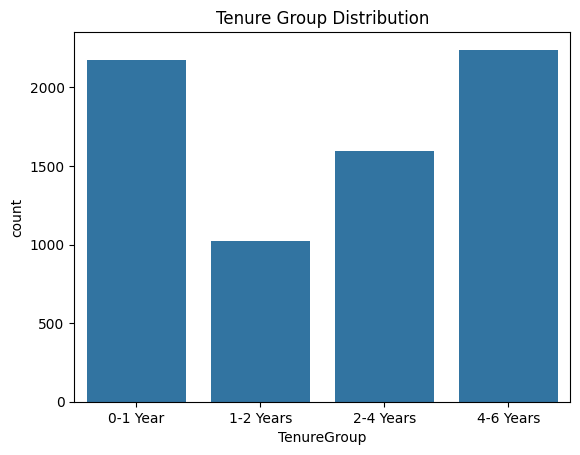

In [9]:
# =========================================
# 9. Visualize Tenure Group Distribution
# =========================================

sns.countplot(x='TenureGroup', data=df)

plt.title("Tenure Group Distribution")

plt.show()

In [10]:
# =========================================
# 10. Create Monthly Charges Category
# =========================================

df['MonthlyChargesCategory'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 70, 120],
    labels=['Low', 'Medium', 'High']
)

In [11]:
# =========================================
# 11. Display Monthly Charges Category Counts
# =========================================

df['MonthlyChargesCategory'].value_counts()

,count
MonthlyChargesCategory,
High,3581
Low,1729
Medium,1722


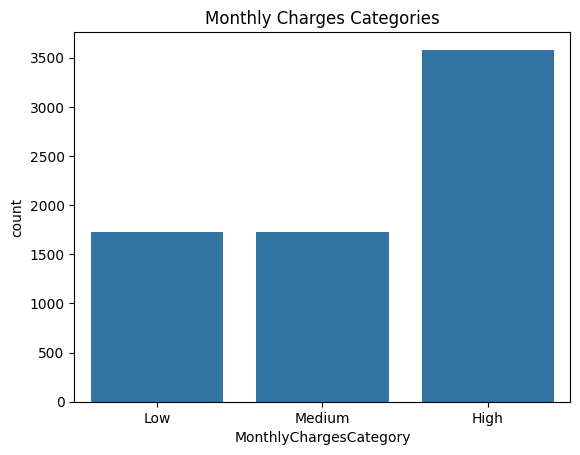

In [12]:
# =========================================
# 12. Visualize Monthly Charges Categories
# =========================================

sns.countplot(x='MonthlyChargesCategory', data=df)

plt.title("Monthly Charges Categories")

plt.show()

In [13]:
# =========================================
# 13. Create Total Charges Category
# =========================================

df['TotalChargesCategory'] = pd.cut(
    df['TotalCharges'],
    bins=[0, 1000, 3000, 9000],
    labels=['Low', 'Medium', 'High']
)

In [14]:
# =========================================
# 14. Display Total Charges Category Counts
# =========================================

df['TotalChargesCategory'].value_counts()

,count
TotalChargesCategory,
Low,2893
High,2204
Medium,1935


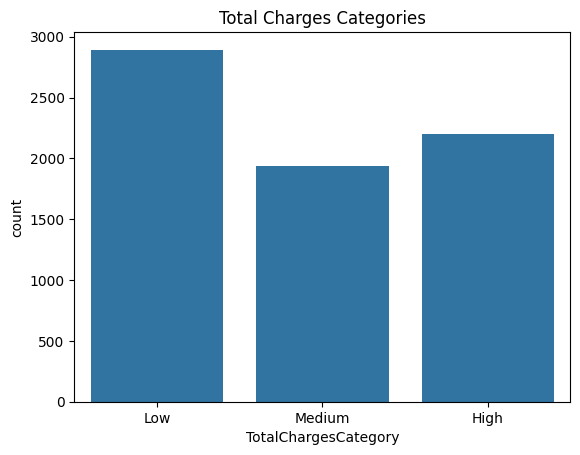

In [15]:
# =========================================
# 15. Visualize Total Charges Categories
# =========================================

sns.countplot(x='TotalChargesCategory', data=df)

plt.title("Total Charges Categories")

plt.show()

In [16]:
# =========================================
# 16. Create Average Monthly Spend Feature
# =========================================

df['AverageMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [17]:
# =========================================
# 17. Display Average Monthly Spend
# =========================================

df['AverageMonthlySpend'].head()

,AverageMonthlySpend
0,14.925000
1,53.985714
2,36.050000
3,40.016304
4,50.550000


In [18]:
# =========================================
# 18. Create Customer Engagement Score
# =========================================

df['EngagementScore'] = (
    df['tenure'] +
    df['MonthlyCharges']
)

In [19]:
# =========================================
# 19. Display Engagement Score
# =========================================

df['EngagementScore'].head()

,EngagementScore
0,30.85
1,90.95
2,55.85
3,87.30
4,72.70


In [20]:
# =========================================
# 20. Create Services Count Feature
# =========================================

service_columns = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['ServiceCount'] = (
    (df[service_columns] != 'No').sum(axis=1)
)

In [21]:
# =========================================
# 21. Display Service Count
# =========================================

df['ServiceCount'].head()

,ServiceCount
0,3
1,4
2,4
3,5
4,2


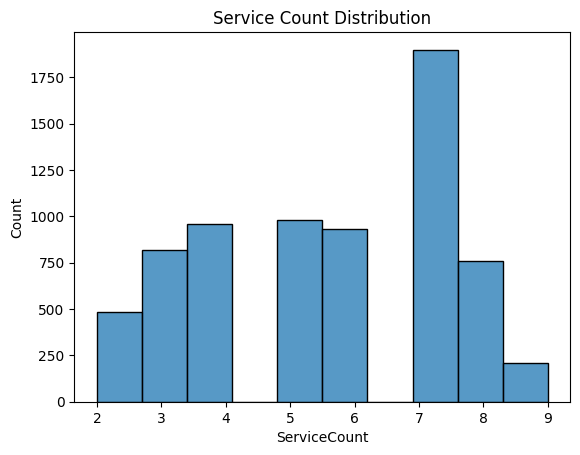

In [22]:
# =========================================
# 22. Visualize Service Count
# =========================================

sns.histplot(df['ServiceCount'], bins=10)

plt.title("Service Count Distribution")

plt.show()

In [23]:
# =========================================
# 23. Create Long-Term Customer Feature
# =========================================

df['LongTermCustomer'] = np.where(df['tenure'] >= 24, 1, 0)

In [24]:
# =========================================
# 24. Display Long-Term Customer Counts
# =========================================

df['LongTermCustomer'].value_counts()

,count
LongTermCustomer,
1,3927
0,3105


In [25]:
# =========================================
# 25. Create High Monthly Charges Feature
# =========================================

df['HighMonthlyCharges'] = np.where(
    df['MonthlyCharges'] > df['MonthlyCharges'].median(),
    1,
    0
)

In [26]:
# =========================================
# 26. Display High Monthly Charges Counts
# =========================================

df['HighMonthlyCharges'].value_counts()

,count
HighMonthlyCharges,
0,3519
1,3513


In [27]:
# =========================================
# 27. Create Paperless Billing Feature
# =========================================

df['PaperlessBillingFlag'] = df['PaperlessBilling'].map({
    'Yes': 1,
    'No': 0
})

In [28]:
# =========================================
# 28. Display Paperless Billing Feature
# =========================================

df['PaperlessBillingFlag'].head()

,PaperlessBillingFlag
0,1
1,0
2,1
3,0
4,1


In [29]:
# =========================================
# 29. Create Senior Citizen Category
# =========================================

df['SeniorCitizenCategory'] = df['SeniorCitizen'].map({
    0: 'Non-Senior',
    1: 'Senior'
})

In [30]:
# =========================================
# 30. Display Senior Citizen Categories
# =========================================

df['SeniorCitizenCategory'].value_counts()

,count
SeniorCitizenCategory,
Non-Senior,5890
Senior,1142


In [31]:
# =========================================
# 31. Check Newly Created Columns
# =========================================

df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup',
       'MonthlyChargesCategory', 'TotalChargesCategory', 'AverageMonthlySpend',
       'EngagementScore', 'ServiceCount', 'LongTermCustomer',
       'HighMonthlyCharges', 'PaperlessBillingFlag', 'SeniorCitizenCategory'],
      dtype='object')

In [32]:
# =========================================
# 32. Check Missing Values After Feature Engineering
# =========================================

df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [33]:
# =========================================
# 33. Check Dataset Shape After Feature Engineering
# =========================================

df.shape

(7032, 30)

In [34]:
# =========================================
# 34. Display Final Dataset
# =========================================

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TenureGroup,MonthlyChargesCategory,TotalChargesCategory,AverageMonthlySpend,EngagementScore,ServiceCount,LongTermCustomer,HighMonthlyCharges,PaperlessBillingFlag,SeniorCitizenCategory
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,0-1 Year,Low,Low,14.925000,30.85,3,0,0,1,Non-Senior
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,2-4 Years,Medium,Medium,53.985714,90.95,4,1,0,0,Non-Senior
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,0-1 Year,Medium,Low,36.050000,55.85,4,0,0,1,Non-Senior
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,2-4 Years,Medium,Medium,40.016304,87.30,5,1,0,0,Non-Senior
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,0-1 Year,High,Low,50.550000,72.70,2,0,1,1,Non-Senior


In [35]:
# =========================================
# 35. Save Feature Engineered Dataset
# =========================================

df.to_csv("feature_engineered_telco_churn.csv", index=False)

In [36]:
# =========================================
# 36. Feature Engineering Summary
# =========================================

print("1. Tenure group feature created.")
print("2. Monthly charges category feature created.")
print("3. Total charges category feature created.")
print("4. Average monthly spend feature created.")
print("5. Engagement score feature created.")
print("6. Service count feature created.")
print("7. Long-term customer feature created.")
print("8. High monthly charges feature created.")
print("9. Paperless billing feature created.")
print("10. Senior citizen category feature created.")

1. Tenure group feature created.
2. Monthly charges category feature created.
3. Total charges category feature created.
4. Average monthly spend feature created.
5. Engagement score feature created.
6. Service count feature created.
7. Long-term customer feature created.
8. High monthly charges feature created.
9. Paperless billing feature created.
10. Senior citizen category feature created.


In [37]:
# =========================================
# 37. Final Conclusion
# =========================================

print("Feature engineering completed successfully.")

Feature engineering completed successfully.
